In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns

In [61]:
first_drop = pd.read_csv("first_drop.csv")
later_drops = pd.read_csv("later_drops.csv")
display(first_drop)
later_drops

,Race,Datetime,D,Total Votes Cast,Dem_Prop_Before_11_08
0,AD-58,2024-11-07 17:37:00,48086,98720,0.487095
1,CD-13,2024-11-07 17:37:00,55625,114417,0.486160
2,CD-21,2024-11-07 17:37:00,64986,128496,0.505743
3,CD-22,2024-11-07 17:37:00,45679,101615,0.449530
4,CD-40,2024-11-07 17:37:00,130259,298774,0.435978
5,CD-41,2024-11-07 17:37:00,119833,247121,0.484916
6,CD-45,2024-11-07 17:37:00,117564,244488,0.480858
7,CD-47,2024-11-07 17:37:00,137577,275770,0.498883
8,CD-49,2024-11-07 17:37:00,145722,285076,0.511169
9,CD-9,2024-11-07 17:37:00,74163,146313,0.506879


,Race,Batch_ID,New_Dem_Prop,New_Total,Votes_Remaining
114,CD-40,3,0.472248,15098.0,69763
310,SD-37,3,0.521319,17168.0,86309
2,AD-58,3,0.571429,84.0,57184
338,SD-5,3,0.642334,21590.0,155041
86,CD-22,3,0.495509,13804.0,52088
...,...,...,...,...,...
81,CD-21,27,0.590059,2354.0,0
137,CD-40,27,0.432432,74.0,0
109,CD-22,27,0.471910,89.0,0
165,CD-41,27,0.409091,66.0,0


In [4]:
race_names = later_drops['Race'].unique()
n_races = len(race_names)

race_idx = later_drops['Race'].astype('category').cat.codes.values
race_idx

array([ 2,  6,  3,  7,  1,  4,  0,  8, 10, 12, 11,  9,  5,  6,  9,  7,  4,
        8, 10, 11,  3,  0, 12,  1,  6, 10, 11, 12,  4,  6,  8,  7,  0,  4,
        5,  9,  0, 12,  1, 10,  1, 11,  6,  0,  7,  8,  4, 10,  2,  9,  3,
        3,  2,  5,  4, 12, 11,  2,  3,  8, 10,  5,  4,  6,  7,  9,  0,  1,
        6, 11,  0,  3,  5,  7,  8,  1, 10,  2,  9,  4,  9,  1,  6,  8, 10,
        2,  5, 11,  7, 12,  4,  3,  0,  4,  8,  0,  6, 10, 11,  5,  7,  1,
        2, 10,  9,  1,  0, 11,  7, 12,  6,  2,  4,  5,  8,  3,  9,  7,  0,
       10,  5,  8,  3,  1,  4, 11,  6,  9,  0,  2, 12, 11,  7,  6,  4,  3,
        1,  8,  5, 10,  4,  9,  7,  0,  8,  5, 10,  1,  6, 11,  3,  2,  8,
        7,  4, 11,  6,  1, 12, 10,  3,  0,  2,  9,  5,  0,  1, 11, 10,  8,
        7,  4,  5,  6, 11,  6,  1,  8,  5,  7,  0,  2, 12,  4, 10,  3,  9,
        7,  3, 10,  1,  6,  0, 11,  5,  8,  4,  9,  6, 10,  4,  9, 12,  3,
        1,  2,  5,  7, 11,  0,  8,  1,  9, 12,  3,  9,  0,  8,  4,  7,  6,
       11, 12, 10,  1,  5

In [5]:
b_rt_observed = later_drops['New_Dem_Prop'].values

Start with $\mu_r, \sigma_r^2, \mu_g, \sigma_g^2$ all constant to make sure it works.

In [6]:
with pm.Model() as election_model_v0:
    
    # =========================================================
    # LEFT SIDE: Race-Specific Hierarchical Component (The R Plate)
    # =========================================================
    # NIX_r prior translated into standard independent priors
    mu_r = 0 #pm.Normal('mu_r', mu=0.5, sigma=0.1)       # Baseline Dem lean across all races
    sigma_r = 0.05 #pm.HalfNormal('sigma_r', sigma=0.1)     # How much variance there is between races
    
    # s_r node (Inside the R plate)
    # The latent state for each individual race (shape = n_races)
    s_r = pm.Normal('s_r', mu=mu_r, sigma=sigma_r, shape=n_races)
    
    
    # =========================================================
    # RIGHT SIDE: Global Component (Outside the plates)
    # =========================================================
    # NIX_g prior 
    mu_g = 0 #pm.Normal('mu_g', mu=0.0, sigma=0.05)      # Expected global shift 
    sigma_g = 0.05 #pm.HalfNormal('sigma_g', sigma=0.05)    # Variance of the global shift
    
    # s_g node
    # A single latent global effect affecting all batches/races equally
    s_g = pm.Normal('s_g', mu=mu_g, sigma=sigma_g)


    # =========================================================
    # CENTER: The Observation Layer (The T Plate nested in R)
    # =========================================================
    # The expected value for each specific batch update is the sum of its 
    # race-specific effect and the global effect.
    # We use race_idx to broadcast the right s_r to the right row.
    expected_b = s_r[race_idx] + s_g + first_drop["Dem_Prop_Before_11_08"].values[race_idx]
    
    # Observation noise (Implicit in continuous generative models)
    sigma_batch = 0.05
    
    # b_{r,t} node (Shaded = observed data)
    b_rt = pm.Normal('b_rt', 
                     mu=expected_b, 
                     sigma=sigma_batch, 
                     observed=b_rt_observed)

In [63]:
with election_model_v0:
    # This runs Markov Chain Monte Carlo (MCMC) to find the most likely 
    # values for all your latent variables (s_r, s_g, etc.) based on your data.
    trace_v0 = pm.sample(draws=2000, tune=1000, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [s_r, s_g]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


In [ ]:
# This generates the classic two-column plot: 
# Left side = the posterior distributions
# Right side = the "caterpillar" plots showing the path of the 4 chains
az.plot_trace(trace_v0)
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as election_model_v1:
    
    # 1. Hyperparameters
    # mu_r is completely GONE. 
    sigma_r = pm.HalfNormal('sigma_r', sigma=0.05)     
    
    # The global shift now handles the entire baseline mean
    mu_g = pm.Normal('mu_g', mu=0.0, sigma=0.05)      
    sigma_g = pm.HalfNormal('sigma_g', sigma=0.05)    
    
    sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.05)

    # 2. Race-Specific Latent State (Non-centered, mean fixed to 0)
    z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
    
    # s_r is now just the race's specific deviation from the global trend
    s_r = pm.Deterministic('s_r', z_r * sigma_r) 
    
    # 3. Global Latent State (Non-centered)
    z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
    s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

    # 4. Observation Layer 
    baseline = first_drop["Dem_Prop_Before_11_08"].values[race_idx]
    
    expected_b = s_r[race_idx] + s_g + baseline
    
    b_rt = pm.Normal('b_rt', 
                     mu=expected_b, 
                     sigma=sigma_batch, 
                     observed=b_rt_observed)

In [ ]:
with election_model_v1:
    # This runs Markov Chain Monte Carlo (MCMC) to find the most likely 
    # values for all your latent variables (s_r, s_g, etc.) based on your data.
    trace_v1 = pm.sample(draws=2000, tune=1000, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, mu_g, sigma_g, sigma_batch, z_r, z_g]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 32 seconds.


In [ ]:
az.plot_trace(trace_v1)
plt.tight_layout()
plt.show()

In [ ]:
all_races = np.unique(np.concatenate((first_drop['Race'], later_drops['Race'])))
n_races = len(all_races)

# 2. Create a Pandas CategoricalDtype to enforce the exact same mapping everywhere
race_cat_type = pd.CategoricalDtype(categories=all_races, ordered=True)

# 3. Apply this EXACT mapping to both dataframes
first_drop['race_idx'] = first_drop['Race'].astype(race_cat_type).cat.codes
later_drops['race_idx'] = later_drops['Race'].astype(race_cat_type).cat.codes

# 4. Extract the baseline array, strictly sorted by the new integer index
first_drop_sorted = first_drop.sort_values('race_idx')
baseline_array = first_drop_sorted['Dem_Prop_Before_11_08'].values

# 5. Extract your time-series batches
batches = sorted(later_drops['Batch_ID'].unique())
model_traces = {}

In [ ]:
for current_batch in batches:
    print(f"--- Training model up to Batch ID: {current_batch} ---")
    
    # Filter data cumulatively up to the current batch
    cumulative_drops = later_drops[later_drops['Batch_ID'] <= current_batch]
    
    # Prepare PyMC inputs as numpy arrays for this specific iteration
    obs_race_idx = cumulative_drops['race_idx'].values
    obs_b_rt = cumulative_drops['New_Dem_Prop'].values
    
    # Map the baseline to match the shape of the current observations
    obs_baseline = baseline_array[obs_race_idx]
    
    with pm.Model() as election_model_v1:
        
        # 1. Hyperparameters
        sigma_r = pm.HalfNormal('sigma_r', sigma=0.05)     
        mu_g = pm.Normal('mu_g', mu=0.0, sigma=0.05)      
        sigma_g = pm.HalfNormal('sigma_g', sigma=0.05)    
        sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.05)

        # 2. Race-Specific Latent State (Non-centered)
        z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
        s_r = pm.Deterministic('s_r', z_r * sigma_r) 
        
        # 3. Global Latent State (Non-centered)
        z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
        s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

        # 4. Observation Layer 
        # expected_b aligns perfectly because obs_race_idx pulls the correct
        # race-specific deviation (s_r) and baseline for every single row
        expected_b = s_r[obs_race_idx] + s_g + obs_baseline
        
        b_rt = pm.Normal('b_rt', 
                         mu=expected_b, 
                         sigma=sigma_batch, 
                         observed=obs_b_rt)
        
        # Sample the posterior
        # progressbar=False keeps the terminal output clean during the loop
        trace = pm.sample(
            draws=2000, 
            tune=1000, 
            chains=4, 
            cores=4, 
            target_accept=0.99, 
            progressbar=False,
            random_seed=42
        )
        
    # Store the trace keyed by the batch ID
    model_traces[current_batch] = trace

print("Sequential training complete. Traces are stored in the 'model_traces' dictionary.")

In [ ]:
os.mkdir("v1_traces")

for current_batch in batches:
    file_path = f"v1_traces/trace_batch_{current_batch}.nc"
    model_traces[current_batch].to_netcdf(file_path)

In [32]:
model_traces = {}

# Assuming you still have your 'batches' list, or you can just hardcode the IDs
batches = sorted(later_drops['Batch_ID'].unique())

for current_batch in batches:
    file_path = f"v1_traces/trace_batch_{current_batch}.nc"
    
    if os.path.exists(file_path):
        # Load the trace from disk back into memory
        model_traces[current_batch] = az.from_netcdf(file_path)
        print(f"Loaded Batch {current_batch} successfully.")
    else:
        print(f"File not found: {file_path}")

Loaded Batch 3 successfully.
Loaded Batch 4 successfully.
Loaded Batch 5 successfully.
Loaded Batch 7 successfully.
Loaded Batch 8 successfully.
Loaded Batch 9 successfully.
Loaded Batch 10 successfully.
Loaded Batch 11 successfully.
Loaded Batch 12 successfully.
Loaded Batch 13 successfully.
Loaded Batch 14 successfully.
Loaded Batch 15 successfully.
Loaded Batch 16 successfully.
Loaded Batch 17 successfully.
Loaded Batch 18 successfully.
Loaded Batch 19 successfully.
Loaded Batch 20 successfully.
Loaded Batch 21 successfully.
Loaded Batch 22 successfully.
Loaded Batch 23 successfully.
Loaded Batch 24 successfully.
Loaded Batch 25 successfully.
Loaded Batch 26 successfully.
Loaded Batch 27 successfully.


In [ ]:
for batch in batches:
    tmp = az.summary(model_traces[batch], var_names=["mu_g", "sigma_g", "sigma_r", "sigma_batch"])
    print(f"batch {batch} --- min ess_bulk: {tmp['ess_bulk'].min()}, min ess_tail: {tmp['ess_tail'].min()} max r_hat: {tmp['r_hat'].max()}")

batch 3 --- min ess_bulk: 437.0, min ess_tail: 437.0 max r_hat: 1.01
batch 4 --- min ess_bulk: 3071.0, min ess_tail: 3408.0 max r_hat: 1.0
batch 5 --- min ess_bulk: 2222.0, min ess_tail: 2165.0 max r_hat: 1.0
batch 7 --- min ess_bulk: 1828.0, min ess_tail: 1574.0 max r_hat: 1.0
batch 8 --- min ess_bulk: 1940.0, min ess_tail: 1698.0 max r_hat: 1.0
batch 9 --- min ess_bulk: 2130.0, min ess_tail: 1656.0 max r_hat: 1.0
batch 10 --- min ess_bulk: 1971.0, min ess_tail: 1634.0 max r_hat: 1.0
batch 11 --- min ess_bulk: 2338.0, min ess_tail: 3050.0 max r_hat: 1.0
batch 12 --- min ess_bulk: 2212.0, min ess_tail: 3446.0 max r_hat: 1.0
batch 13 --- min ess_bulk: 2429.0, min ess_tail: 3161.0 max r_hat: 1.0
batch 14 --- min ess_bulk: 2086.0, min ess_tail: 2950.0 max r_hat: 1.0
batch 15 --- min ess_bulk: 2065.0, min ess_tail: 2387.0 max r_hat: 1.0
batch 16 --- min ess_bulk: 2269.0, min ess_tail: 3078.0 max r_hat: 1.0
batch 17 --- min ess_bulk: 2079.0, min ess_tail: 2261.0 max r_hat: 1.0
batch 18 --- 

In [ ]:
# We only want the meaningful parameters, not the raw non-centered 'z' values
target_vars = ["mu_g", "sigma_g", "sigma_r", "sigma_batch", "s_g", "s_r"]

summary_list = []

# Loop through your saved/loaded traces
for batch_id, trace in model_traces.items():
    
    # Extract the summary stats for this batch
    # (hdi_prob=0.94 is the ArviZ default, you can change it if needed)
    batch_summary = az.summary(trace, var_names=target_vars, hdi_prob=0.94)
    
    # The index contains strings like "mu_g" or "s_r[0]". Move it to a column.
    batch_summary = batch_summary.reset_index(names="pymc_param")
    
    # Tag with the current Batch ID
    batch_summary['Batch_ID'] = batch_id
    
    # Keep only the essential columns to keep it tidy
    batch_summary = batch_summary[['Batch_ID', 'pymc_param', 'mean', 'sd', 'hdi_3%', 'hdi_97%']]
    
    summary_list.append(batch_summary)

# Combine everything into one master DataFrame
latent_df = pd.concat(summary_list, ignore_index=True)

# ---------------------------------------------------------
# Parse parameter names and map indices back to Race names
# ---------------------------------------------------------
def extract_param_and_race(param_string):
    # Uses regex to check if the string has brackets, e.g., "s_r[12]"
    match = re.match(r"([a-zA-Z_]+)\[(\d+)\]", param_string)
    if match:
        param_name = match.group(1) # "s_r"
        idx = int(match.group(2))   # 12
        # Use the 'all_races' array we defined in the preprocessing step
        race_name = all_races[idx]  
        return param_name, race_name
    else:
        # For global parameters like "mu_g" or "s_g"
        return param_string, None

# Apply the parsing function
parsed_cols = latent_df['pymc_param'].apply(extract_param_and_race)

# Split the results into two new clean columns
latent_df['Parameter'] = [x[0] for x in parsed_cols]
latent_df['Race'] = [x[1] for x in parsed_cols]

# Drop the messy PyMC string and reorder columns for readability
latent_df = latent_df.drop(columns=['pymc_param'])
latent_df = latent_df[['Batch_ID', 'Parameter', 'Race', 'mean', 'sd', 'hdi_3%', 'hdi_97%']]

latent_df

,Batch_ID,Parameter,Race,mean,sd,hdi_3%,hdi_97%
0,3,mu_g,NaN,0.018,0.030,-0.042,0.075
1,3,sigma_g,NaN,0.035,0.027,0.000,0.083
2,3,sigma_r,NaN,0.038,0.021,0.000,0.070
3,3,sigma_batch,NaN,0.041,0.020,0.003,0.073
4,3,s_g,NaN,0.025,0.017,-0.008,0.058
...,...,...,...,...,...,...,...
427,27,s_r,CD-49,-0.032,0.019,-0.070,0.003
428,27,s_r,CD-9,-0.081,0.020,-0.119,-0.044
429,27,s_r,SD-19,-0.048,0.019,-0.084,-0.012
430,27,s_r,SD-37,0.037,0.020,0.001,0.075


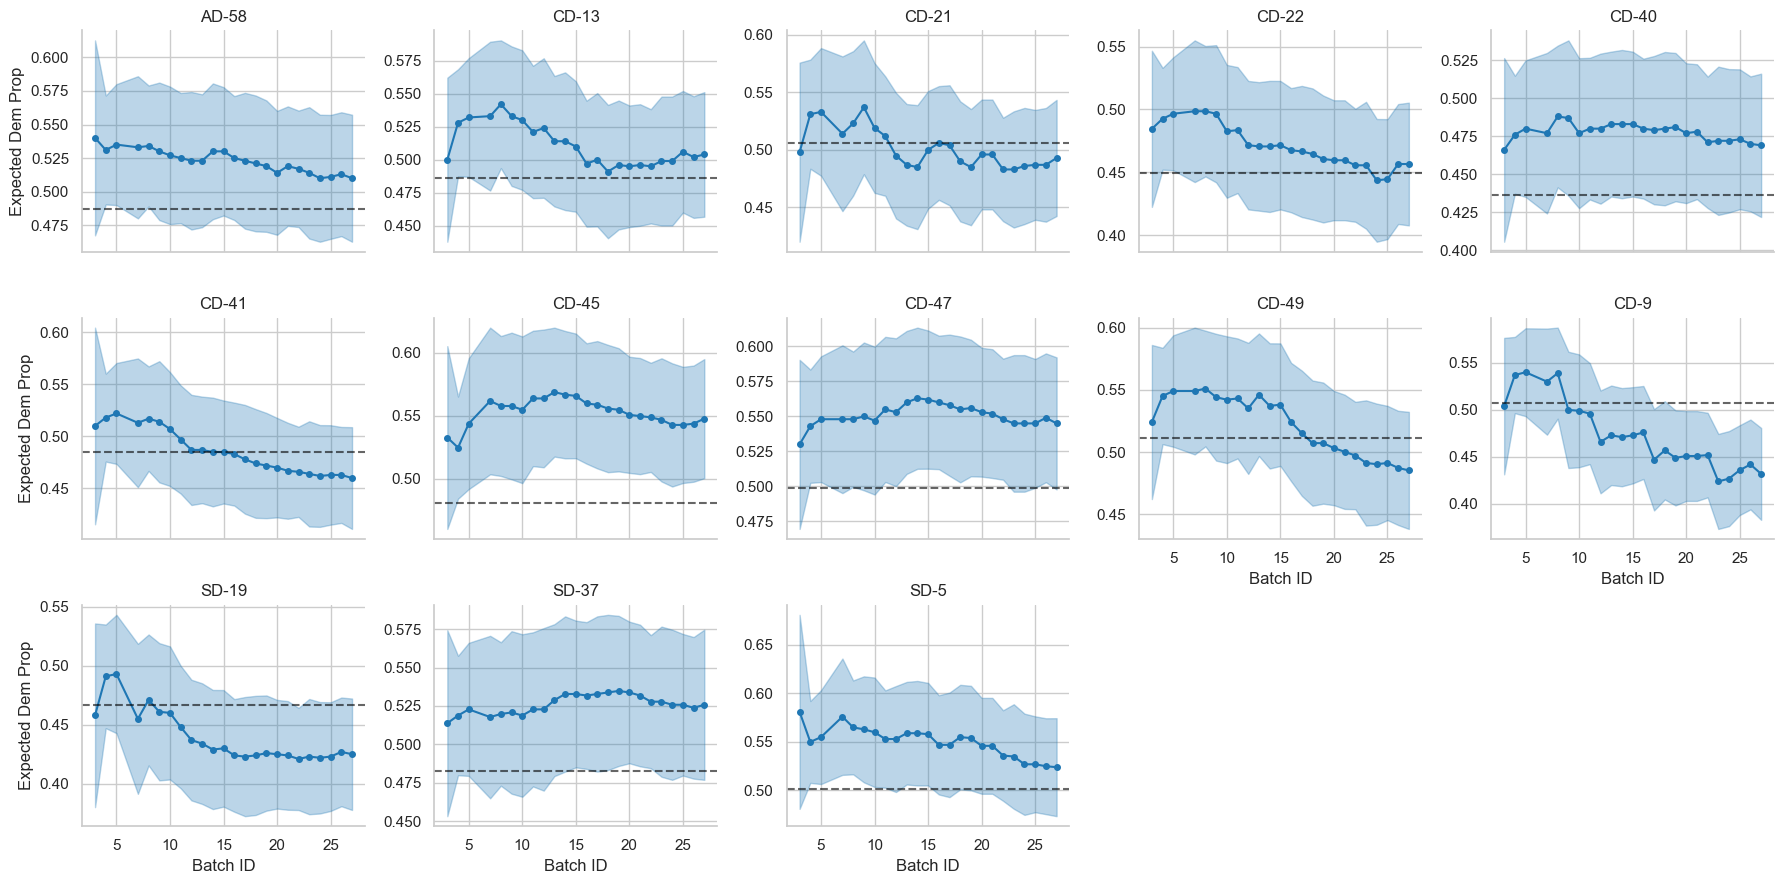

In [ ]:
df_sr = latent_df[latent_df['Parameter'] == 's_r'].copy()
df_sr = df_sr.rename(columns={'mean': 'sr_mean', 'sd': 'sr_sd'})

# Filter out s_g and rename columns (it has no Race column, so we drop it)
df_sg = latent_df[latent_df['Parameter'] == 's_g'].copy()
df_sg = df_sg[['Batch_ID', 'mean', 'sd']].rename(columns={'mean': 'sg_mean', 'sd': 'sg_sd'})

# Merge s_r and s_g on Batch_ID
plot_df = pd.merge(df_sr, df_sg, on='Batch_ID', how='left')

# Map the baseline values from your first_drop dataframe
baseline_dict = dict(zip(first_drop['Race'], first_drop['Dem_Prop_Before_11_08']))
plot_df['baseline'] = plot_df['Race'].map(baseline_dict)

# ---------------------------------------------------------
# 2. Calculate Expected Means and 2SD Bands
# ---------------------------------------------------------
# Expected Dem Prop = Baseline + s_r + s_g
plot_df['expected_mean'] = plot_df['baseline'] + plot_df['sr_mean'] + plot_df['sg_mean']

# Combined SD assuming independence
plot_df['combined_sd'] = np.sqrt(plot_df['sr_sd']**2 + plot_df['sg_sd']**2)

# Upper and Lower 2SD bounds
plot_df['upper_2sd'] = plot_df['expected_mean'] + (2 * plot_df['combined_sd'])
plot_df['lower_2sd'] = plot_df['expected_mean'] - (2 * plot_df['combined_sd'])

# Sort for clean line plotting
plot_df = plot_df.sort_values(['Race', 'Batch_ID'])

# ---------------------------------------------------------
# 3. Plotting with Seaborn FacetGrid
# ---------------------------------------------------------
def plot_expected_bands(data, **kwargs):
    ax = plt.gca()
    
    # Plot the 2SD uncertainty band
    ax.fill_between(data['Batch_ID'], data['lower_2sd'], data['upper_2sd'], alpha=0.3, color='#1f77b4')
    
    # Plot the expected mean over time
    ax.plot(data['Batch_ID'], data['expected_mean'], color='#1f77b4', marker='o', markersize=4)
    
    # Add the static baseline as a reference dashed line
    ax.axhline(data['baseline'].iloc[0], color='black', linestyle='--', alpha=0.6, label='Baseline')

# Set up the grid (adjust col_wrap if you have a massive amount of races)
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(plot_df, col="Race", col_wrap=5, sharey=False, height=3, aspect=1.2)

# Map our custom plotting function to the grid
g.map_dataframe(plot_expected_bands)

# Clean up labels
g.set_axis_labels("Batch ID", "Expected Dem Prop")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
# Merge actual observed batch proportions into plot_df
actual_df = later_drops[['Race', 'Batch_ID', 'New_Dem_Prop']].copy()
plot_df_with_actual = pd.merge(plot_df, actual_df, on=['Race', 'Batch_ID'], how='left')
plot_df_with_actual = plot_df_with_actual.sort_values(['Race', 'Batch_ID'])

def plot_expected_and_actual(data, **kwargs):
    ax = plt.gca()

    # 2SD uncertainty band
    ax.fill_between(data['Batch_ID'], data['lower_2sd'], data['upper_2sd'],
                    alpha=0.25, color='#1f77b4')

    # Model expected mean
    ax.plot(data['Batch_ID'], data['expected_mean'],
            color='#1f77b4', marker='o', markersize=4, label='Model estimate')

    # Actual observed batch proportions
    ax.scatter(data['Batch_ID'], data['New_Dem_Prop'],
               color='orange', zorder=5, s=20, label='Observed batch')

    # First-drop baseline
    ax.axhline(data['baseline'].iloc[0], color='black',
               linestyle='--', alpha=0.6, label='Baseline')

sns.set_theme(style="whitegrid")
g = sns.FacetGrid(plot_df_with_actual, col="Race", col_wrap=5,
                  sharey=False, height=3, aspect=1.2)
g.map_dataframe(plot_expected_and_actual)
g.set_axis_labels("Batch ID", "Dem Prop")
g.set_titles(col_template="{col_name}")

# Single shared legend on the first panel
handles = [
    plt.Line2D([0], [0], color='#1f77b4', marker='o', markersize=4, label='Model estimate'),
    plt.scatter([], [], color='orange', s=20, label='Observed batch'),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.6, label='Baseline'),
]
g.axes[0].legend(handles=handles, fontsize=7, loc='best')

plt.tight_layout()
plt.show()


Note the above plot does not sample from the joint posterior, it treats each of the marginal conditionals $p(\theta_i|X)$ as independent Gaussians (just for simplicity for now). Confidence regions are 2SDs in each direction.

In [35]:
import numpy as np

extracted_posteriors = {}

for current_batch, trace in model_traces.items():
    
    # 1. Extract the raw multi-dimensional arrays
    s_r_raw = trace.posterior["s_r"].values               # Shape: (chains, draws, n_races)
    s_g_raw = trace.posterior["s_g"].values               # Shape: (chains, draws)
    sig_batch_raw = trace.posterior["sigma_batch"].values # Shape: (chains, draws)
    
    # 2. Flatten the chains and draws together into one long sequence
    s_r_flat = s_r_raw.reshape(-1, s_r_raw.shape[-1]) # Shape: (total_samples, n_races)
    s_g_flat = s_g_raw.flatten()                      # Shape: (total_samples,)
    sig_batch_flat = sig_batch_raw.flatten()          # Shape: (total_samples,)
    
    # 3. Calculate the step size to get exactly 1000 draws
    total_samples = len(s_g_flat)
    step = total_samples // 1000
    
    # 4. Slice the arrays evenly and cap at exactly 1000 (just in case of weird math)
    s_r_1000 = s_r_flat[::step][:1000]
    s_g_1000 = s_g_flat[::step][:1000]
    sig_batch_1000 = sig_batch_flat[::step][:1000]
    
    # 5. Calculate the expected Dem Prop for ALL races
    expected_b_1000 = s_r_1000 + s_g_1000[:, np.newaxis] + baseline_array
    
    # Store the parameters
    extracted_posteriors[current_batch] = {
        "expected_b": expected_b_1000,   # Shape: (1000, n_races)
        "sigma_batch": sig_batch_1000    # Shape: (1000,)
    }

print("Evenly spaced posterior draws extracted and stored in 'extracted_posteriors'.")

Evenly spaced posterior draws extracted and stored in 'extracted_posteriors'.


In [53]:
# Use NumPy's random generator (the equivalent of rnorm)
rng = np.random.default_rng(seed=42)

simulated_future_batches = {}
total_batches = len(batches)

# We only need to loop over the batches (k)
for i, current_batch in enumerate(batches):
    
    # How many batches are left to simulate? (k - i - 1)
    n_remaining = total_batches - i - 1
    
    if n_remaining > 0:
        # 1. Grab the parameters from the dictionary
        # expected_b shape: (1000, n_races)
        # sigma_batch shape: (1000,)
        exp_b_1000 = extracted_posteriors[current_batch]['expected_b']
        sig_batch_1000 = extracted_posteriors[current_batch]['sigma_batch']
        
        n_races = exp_b_1000.shape[1]
        
        # 2. Reshape them to allow for a new "remaining batches" dimension in the middle
        # exp_b_reshaped becomes (1000, 1, 13)
        exp_b_reshaped = exp_b_1000[:, np.newaxis, :]
        
        # sig_batch_reshaped becomes (1000, 1, 1)
        sig_batch_reshaped = sig_batch_1000[:, np.newaxis, np.newaxis]
        
        # 3. Draw the samples!
        # By passing 'size', NumPy automatically copies the means and standard deviations 
        # across the 'n_remaining' dimension.
        # Output shape: (1000, n_remaining, 13)
        simulations = rng.normal(
            loc=exp_b_reshaped, 
            scale=sig_batch_reshaped, 
            size=(1000, n_remaining, n_races)
        )
        
        simulated_future_batches[current_batch] = simulations
        
    else:
        # For the final batch, there are 0 remaining batches
        simulated_future_batches[current_batch] = None

print("Future batch simulations complete.")

Future batch simulations complete.


(23, 13)

Next Steps: Scale variance by $(\text{drop size})^{-1/2}$